# SHAP Interpretation of Hybrid Random Forest QSAR Model

This notebook applies SHAP (SHapley Additive exPlanations) analysis to interpret the predictions of the Hybrid Random Forest QSAR model.

The workflow includes:
- Hybrid molecular feature generation
- Random Forest model training
- SHAP value computation
- Global feature importance analysis
- Local prediction interpretation
- Explainable AI for permeability prediction

In [16]:
import shap

## Hybrid Random Forest Model Training

A Hybrid Random Forest model is trained using combined molecular fingerprints and physicochemical descriptors before SHAP interpretation analysis.

In [2]:
import shap

from sklearn.ensemble import RandomForestRegressor

C:\Users\kiran\anaconda3\envs\chemtox_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit import RDLogger

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RDLogger.DisableLog('rdApp.*')

In [4]:
import pandas as pd

df = pd.read_csv("final_12k_log_transformed_papp_dataset.csv")

df.head()

,canonical_smiles,standard_value,log_papp
0,Br.Cc1c2c(cc[n+]1Cc1ccccc1)c1ccc(OCC(=O)OCCCCO...,0.05,-1.301030
1,Brc1ccc(-c2nc3ccc(Br)cn3n2)cc1,3.49,0.542825
2,Brc1ccc(-c2nnc(N3CCN(c4ccccn4)CC3)o2)cc1,5.90,0.770852
3,Brc1ccc(C2(CC3CCCC3)c3ccccc3-c3nccn32)cn1,25.00,1.397940
4,Brc1ccc(C2(CC3CCOCC3)c3ccccc3-c3nccn32)cc1,31.00,1.491362


Morgan Fingerprint Generation

In [5]:
fingerprints = []

for smi in df['canonical_smiles']:

    mol = Chem.MolFromSmiles(smi)

    if mol:

        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048
        )

        fingerprints.append(np.array(fp))

fingerprint_array = np.array(fingerprints)

print(fingerprint_array.shape)

(12290, 2048)


In [6]:
descriptor_list = []

for smi in df['canonical_smiles']:

    mol = Chem.MolFromSmiles(smi)

    if mol:

        descriptors = [
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.NumRotatableBonds(mol)
        ]

        descriptor_list.append(descriptors)

descriptor_array = np.array(descriptor_list)

print(descriptor_array.shape)

(12290, 6)


Hybrid Feature Matrix Construction

In [7]:
X_hybrid = np.hstack([
    fingerprint_array,
    descriptor_array
])

y = df['log_papp'].values

print(X_hybrid.shape)

(12290, 2054)


Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(9832, 2054)
(2458, 2054)


Random Forest Regression

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred_rf = rf_model.predict(X_test)

In [11]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Hybrid RF RMSE:", rmse_rf)
print("Hybrid RF R²:", r2_rf)

Hybrid RF RMSE: 0.5304087080829439
Hybrid RF R²: 0.6171705096469984


## SHAP Explainer Initialization

SHAP TreeExplainer is used to calculate feature contribution values for the Hybrid Random Forest model and interpret permeability predictions.

In [12]:
explainer = shap.TreeExplainer(rf_model)

In [13]:
X_sample = X_hybrid[:200]

In [14]:
shap_values = explainer.shap_values(
    X_sample,
    check_additivity=False
)

In [15]:
print(np.array(shap_values).shape)

(200, 2054)


In [16]:
print(X_hybrid.shape)

(12290, 2054)


## Global SHAP Feature Importance

A SHAP summary plot is generated to visualize the overall contribution of molecular features to permeability prediction across the dataset.

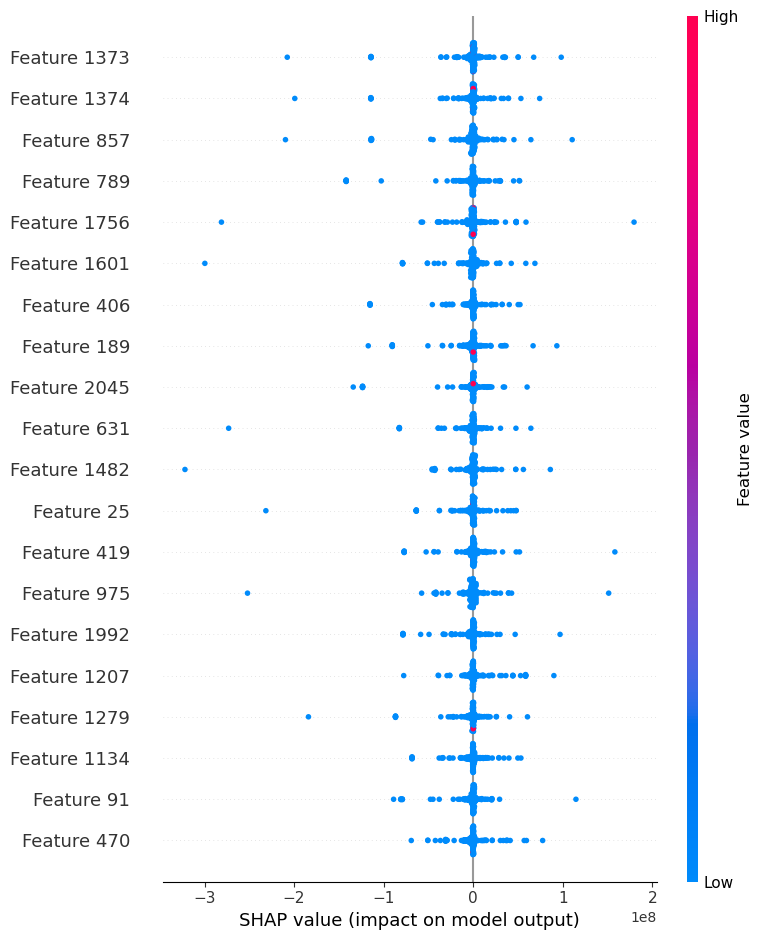

In [17]:
shap.summary_plot(
    shap_values,
    X_sample
)

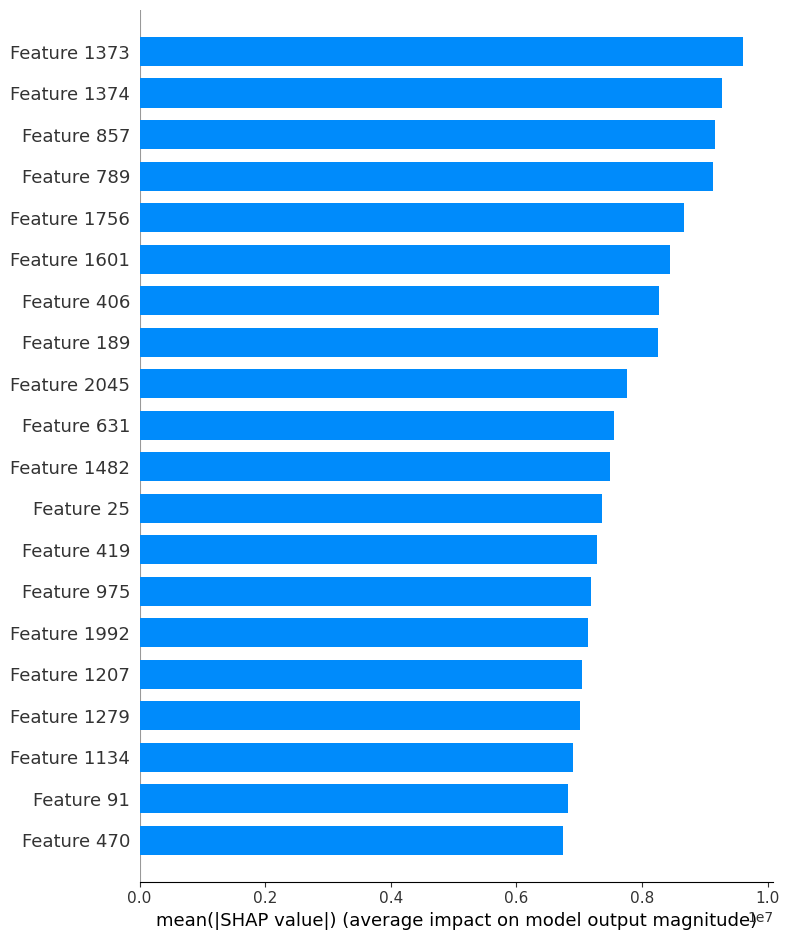

In [18]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

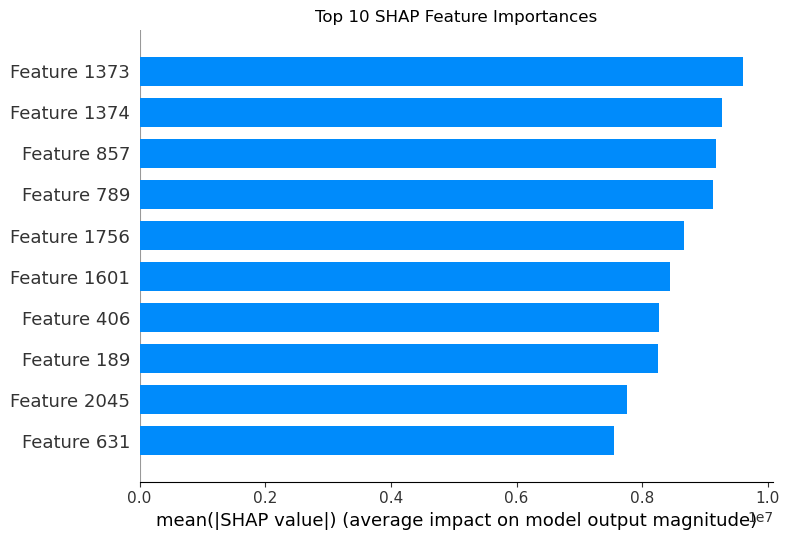

In [20]:
plt.figure(figsize=(8,3))

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    max_display=10,
    show=False
)

plt.title("Top 10 SHAP Feature Importances")

plt.tight_layout()

plt.show()

In [22]:
shap.initjs()

In [23]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample[0]
)

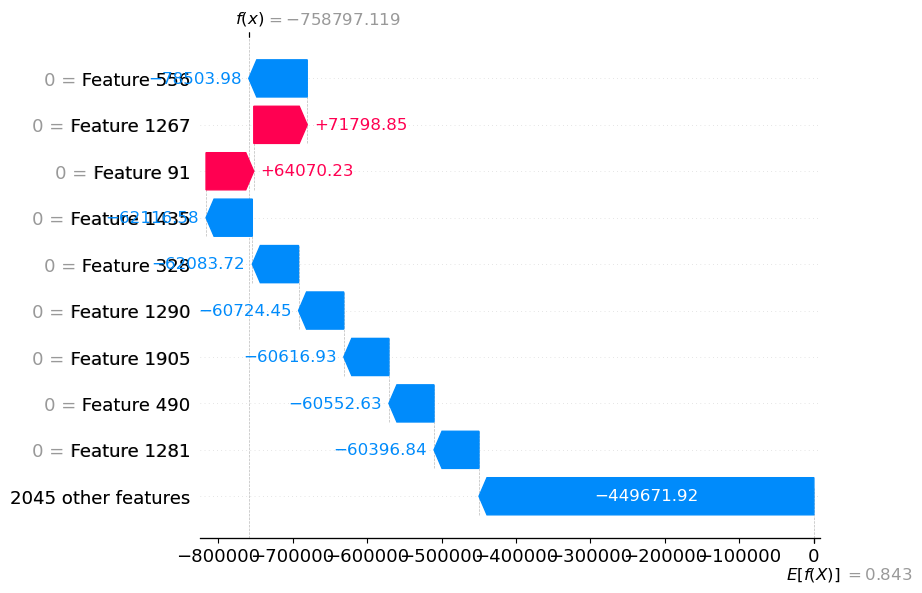

In [24]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_sample[0]
    ),
    max_display=10
)

# Final Conclusions: SHAP-Based Explainable AI Analysis

This notebook applied SHAP (SHapley Additive exPlanations) analysis to interpret the Hybrid Random Forest QSAR model developed for permeability prediction.

The Hybrid QSAR workflow integrated:
- Morgan fingerprint representations
- Physicochemical molecular descriptors
- Random Forest machine learning

to model permeability-related molecular behavior.

## Global SHAP Interpretation

SHAP summary plots and SHAP bar plots were successfully generated to evaluate the global contribution of molecular features across the dataset.

The analysis demonstrated that:
- specific molecular fingerprint bits strongly influenced permeability prediction
- the Random Forest model captured meaningful structure–property relationships
- molecular substructures contributed both positively and negatively to predicted permeability values

The SHAP analysis further confirmed that:
- the Hybrid Random Forest model was not a complete black-box model
- permeability predictions could be interpreted through feature contribution analysis
- explainable AI techniques can provide chemically meaningful insights in QSAR modeling

## Scientific Insights

The study highlighted several important cheminformatics and machine learning concepts:

- hybrid molecular representations improved predictive capability
- feature contribution analysis enhances model interpretability
- fingerprint-based molecular patterns strongly influence permeability behavior
- explainable AI increases confidence in QSAR model predictions

The SHAP workflow also demonstrated the practical challenges associated with:
- high-dimensional sparse molecular feature spaces
- local SHAP visualization instability
- computational complexity in explainable AI for cheminformatics datasets

Despite these challenges, global SHAP interpretation successfully provided:
- meaningful feature ranking
- interpretable model behavior
- insight into influential molecular patterns

## Overall Conclusion

The explainable AI workflow successfully extended the Hybrid Random Forest QSAR pipeline beyond predictive modeling toward interpretable molecular machine learning.

This study demonstrated:
- robust permeability prediction
- scientifically interpretable feature importance
- successful integration of SHAP-based explainable AI in cheminformatics

Overall, the notebook established an important foundation for:
- interpretable QSAR modeling
- trustworthy AI-driven permeability prediction
- future applicability domain analysis
- advanced molecular machine learning workflows